# Notebook For Analysis

# Setup

In [1]:
!echo $HOSTNAME
!python --version
!nvidia-smi

g006
Python 3.12.5
Thu Jun 25 16:29:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off |   00000000:E3:00.0 Off |                    0 |
| N/A   22C    P0             32W /  250W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------

In [2]:
# General Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import os
import tqdm.auto as tqdm
import random
from pathlib import Path
import plotly.express as px
import copy

from typing import List, Union, Optional
from functools import partial
import itertools
from IPython.display import HTML

# CSV Use Libraries
import pandas as pd

# Function Imports
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Unused
"""
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
import ast
from transformers import get_cosine_schedule_with_warmup #Used for lr?
from torch.nn.utils import clip_grad_norm_
"""

'\nfrom torch.utils.data import DataLoader\nfrom transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer\nimport dataclasses\nimport datasets\nimport ast\nfrom transformers import get_cosine_schedule_with_warmup #Used for lr?\nfrom torch.nn.utils import clip_grad_norm_\n'

### Save Directories
- Specify Notebook Directory
- Specify Dataset Directory

In [7]:
import sys

# Add the Catagorical Transformer directory to the path so config.py can be imported
_ct_dir = str(Path(os.getcwd()) / "Catagorical_Transformer")
if _ct_dir not in sys.path:
    sys.path.insert(0, _ct_dir)

from config import *

# Shared helpers live in Transformer.py (the training script). Importing them does
# NOT trigger training — that is guarded by `if __name__ == "__main__"`.
from Transformer import (
    setup_device, build_model, load_and_split_data, load_checkpoint_into,
    descent_loss_fn, descent_accuracy_fn, descent_sequence_accuracy,
    create_attention_mask, register_pad_mask_hook,
)

# DATA_PATH and PTH_LOCATION are now resolved from config.py
print(f"Data Dir:  {DATA_PATH}")
print(f"Model PTH: {PTH_LOCATION}")

Data Dir:  /home/linrya/CoxeterArtinProject/transformer/Summer_2026/Categorical_Transformer
Model PTH: /home/linrya/CoxeterArtinProject/transformer/Summer_2026/Categorical_Transformer/workspace/_scratch/model.pth


## Define Graphing Functs

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")

Using renderer: notebook_connected


In [5]:
pio.templates['plotly'].layout.xaxis.title.font.size = 20
pio.templates['plotly'].layout.yaxis.title.font.size = 20
pio.templates['plotly'].layout.title.font.size = 30

In [6]:
import sys
import transformer_lens
import transformer_lens.utilities as utils
from transformer_lens import HookedTransformer
import transformer_lens.config.hooked_transformer_config as htc
sys.modules['transformer_lens.HookedTransformerConfig'] = sys.modules['transformer_lens.config.hooked_transformer_config']

In [8]:
# Unused plotting functions in favor of Neel Plotly
"""
def imshow(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
    px.imshow(utils.to_numpy(tensor), color_continuous_midpoint=0.0, color_continuous_scale="RdBu", labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

def line(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
    px.line(utils.to_numpy(tensor), labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

def scatter(x, y, xaxis="", yaxis="", caxis="", renderer=None, **kwargs):
    x = utils.to_numpy(x)
    y = utils.to_numpy(y)
    px.scatter(y=y, x=x, labels={"x":xaxis, "y":yaxis, "color":caxis}, **kwargs).show(renderer)
"""

'\ndef imshow(tensor, renderer=None, xaxis="", yaxis="", **kwargs):\n    px.imshow(utils.to_numpy(tensor), color_continuous_midpoint=0.0, color_continuous_scale="RdBu", labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)\n\ndef line(tensor, renderer=None, xaxis="", yaxis="", **kwargs):\n    px.line(utils.to_numpy(tensor), labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)\n\ndef scatter(x, y, xaxis="", yaxis="", caxis="", renderer=None, **kwargs):\n    x = utils.to_numpy(x)\n    y = utils.to_numpy(y)\n    px.scatter(y=y, x=x, labels={"x":xaxis, "y":yaxis, "color":caxis}, **kwargs).show(renderer)\n'

## Set Paths and GPU Devices

In [8]:
# PTH_LOCATION is imported from config.py; create the directory if it doesn't exist yet
os.makedirs(Path(PTH_LOCATION).parent, exist_ok=True)

In [9]:
device, device1 = setup_device()

CUDA available: True
Device count: 1
Device 0: NVIDIA A100-PCIE-40GB
Device Name: cuda


## Define Model and Optimizer Params

**Task:** Coxeter Group input and Binary Classification Output

- `[B,T,C]`
    - Batch Size | dataset size fed into model
    - Sequence Length | ctx
    - Number of Features | d_model

- Sequence (an input):
    - sequence: `[1,2,3,4]`
    - the label: `0` or `1`
    - each token has a `d_model` lengthed "features" vector

In [10]:
torch.manual_seed(seed=DATA_SEED)
torch.cuda.manual_seed_all(DATA_SEED)

# Load architecture + weights from the saved checkpoint. build_model() reconstructs
# the model/optimizer/scheduler (and disables biases); load_checkpoint_into() fills in
# the trained state and returns the training-curve history.
cached_data = torch.load(PTH_LOCATION, weights_only=False)
cfg = cached_data["config"]

model, optimizer, scheduler = build_model(cfg)
_, history = load_checkpoint_into(model, optimizer, scheduler)

model_checkpoints = history["checkpoints"]
checkpoint_epochs = history["checkpoint_epochs"]
train_losses      = history["train_losses"]
test_losses       = history["test_losses"]
train_accuracies  = history["train_accuracies"]
test_accuracies   = history["test_accuracies"]

## Misc Setup
Loss/accuracy/masking functions are imported from `Transformer.py` at the top.

In [11]:
torch.cuda.empty_cache()
clsDex = 0  # index of CLS token, kept for attention pattern analysis

## Initialize Datasets

In [12]:
# Load + shuffle + split + move-to-device, using the same seeded split as training.
data = load_and_split_data(device1)
train_tokens,  test_tokens  = data["train_tokens"],  data["test_tokens"]
train_targets, test_targets = data["train_targets"], data["test_targets"]
train_mask,    test_mask    = data["train_mask"],    data["test_mask"]
train_attention_mask = data["train_attention_mask"]
test_attention_mask  = data["test_attention_mask"]

Loaded dataset: tokens (4000, 22) | targets (4000, 22, 3)
Train size: 1600 | Test size: 2400 | Seq Len: 22


# Graph Results

In [13]:
from neel_plotly.plot import line_or_scatter, line as neel_line

In [14]:
skipBy = 100

def createGraph(yTrain, yTest, yName, title):
    fig = line_or_scatter(
        [yTrain[::skipBy], yTest[::skipBy]],
        x=np.arange(0, len(yTrain), skipBy),
        xaxis="Epoch",
        yaxis=yName,
        log_y=True,
        title=title,
        line_labels=['train', 'test'],
        toggle_x=True,
        toggle_y=True,
        plot_type="line",
        return_fig=True
    )
    return fig

fig1 = createGraph(train_losses, test_losses, "Loss", "Loss Curve for Word Problem")
fig2 = createGraph(train_accuracies, test_accuracies, "Accuracy", "Accuracy Curve for Word Problem")

fig1.show()
fig2.show()

fig1.write_html("loss_curve.html")
fig2.write_html("accuracy_curve.html")

# Analysing the Model

Helpful Memory Probing Functions:

- nvidia-smi
- torch.cuda.empty_cache()
- torch.set_grad_enabled(mode=False)
- gc.collect()
- print(torch.cuda.memory_summary())
- torch profiler also (saved image on Aug 03, 2025 ~6pm)

### Helper Functions
- logit return function
- prediction function

In [15]:
import gc

def getLogits(model: HookedTransformer, tokens, getCache: bool = False):
    """
    Applies the padding mask and runs a forward pass.
    Returns detached logits (and optionally the activation cache).
    """
    with torch.inference_mode():
        model.reset_hooks()
        mask = create_attention_mask(tokens).to(device1)
        register_pad_mask_hook(model, mask)
        if getCache:
            original_logits_og, cache = model.run_with_cache(tokens)
        else:
            original_logits_og = model(tokens)
    original_logits = original_logits_og.detach().clone()
    del original_logits_og, mask
    torch.cuda.empty_cache()
    if getCache:
        return original_logits, cache
    else:
        return original_logits

def getPredictions(model: HookedTransformer, tokens, targets, mask):
    """
    Per-sequence descent accuracy: fraction of prefixes whose descent set is
    exactly correct. Shape: (batch_size,)
    """
    logits  = getLogits(model, tokens, getCache=False)
    seq_acc = descent_sequence_accuracy(logits, targets, mask)
    del logits
    return seq_acc

def imshow(tensor, renderer=None, xaxis="", yaxis="", xlabels=None, ylabels=None, aspect="auto", **kwargs):
    fig = px.imshow(
        utils.to_numpy(tensor),
        color_continuous_midpoint=0.0,
        color_continuous_scale="RdBu",
        labels={"x": xaxis, "y": yaxis},
        aspect=aspect,
        **kwargs
    )
    if xlabels is not None:
        fig.update_xaxes(tickmode='array', tickvals=list(range(len(xlabels))), ticktext=xlabels)
    if ylabels is not None:
        fig.update_yaxes(tickmode='array', tickvals=list(range(len(ylabels))), ticktext=ylabels)
    fig.update_yaxes(scaleanchor=None)
    fig.show(renderer)
    return fig

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

## Quick Analysis + Memory Cleanup

In [16]:
torch.set_grad_enabled(False)
gc.collect()
torch.cuda.empty_cache()

In [17]:
original_logits, cache = getLogits(model, train_tokens, getCache=True)

Get key weight matrices:

In [18]:
W_E = model.embed.W_E[:-1]
print("W_E", W_E.shape)
W_neur = W_E @ model.blocks[0].attn.W_V @ model.blocks[0].attn.W_O @ model.blocks[0].mlp.W_in
print("W_neur", W_neur.shape)
W_logit = model.blocks[0].mlp.W_out @ model.unembed.W_U
print("W_logit", W_logit.shape)

W_E torch.Size([3, 256])
W_neur torch.Size([4, 3, 256])
W_logit torch.Size([256, 3])


In [19]:
original_loss = descent_loss_fn(original_logits, train_targets, train_mask).item()
print("Original Loss:", original_loss)

Original Loss: 0.6034049987792969


### Looking at Activations

Get all shapes:

In [20]:
for param_name, param in cache.items():
    print(param_name, param.shape)

hook_embed torch.Size([1600, 22, 256])
hook_pos_embed torch.Size([1600, 22, 256])
blocks.0.hook_resid_pre torch.Size([1600, 22, 256])
blocks.0.attn.hook_q torch.Size([1600, 22, 4, 64])
blocks.0.attn.hook_k torch.Size([1600, 22, 4, 64])
blocks.0.attn.hook_v torch.Size([1600, 22, 4, 64])
blocks.0.attn.hook_attn_scores torch.Size([1600, 4, 22, 22])
blocks.0.attn.hook_pattern torch.Size([1600, 4, 22, 22])
blocks.0.attn.hook_z torch.Size([1600, 22, 4, 64])
blocks.0.hook_attn_out torch.Size([1600, 22, 256])
blocks.0.hook_resid_mid torch.Size([1600, 22, 256])
blocks.0.mlp.hook_pre torch.Size([1600, 22, 256])
blocks.0.mlp.hook_post torch.Size([1600, 22, 256])
blocks.0.hook_mlp_out torch.Size([1600, 22, 256])
blocks.0.hook_resid_post torch.Size([1600, 22, 256])
unembed.hook_in torch.Size([1600, 22, 256])
unembed.hook_out torch.Size([1600, 22, 3])


In [21]:
# debug: prints the first 4 input train data values
train_tokens[:4]
print(model.W_E.shape)

torch.Size([4, 256])


## Attention Heads (average)

### Average attention over all words for each head
Note: all train data input words used and averaged out for these graphs
- x: letters (keys attended to)
- y: letters (query giving attention to x axis)

In [22]:
n_heads = model.cfg.n_heads
seq_len = model.cfg.n_ctx
str_tokens = [str(i) for i in range(seq_len)]

with torch.inference_mode():
    for layer in range(model.cfg.n_layers):
        head_sums  = None   # reset per layer
        num_samples = 0

        for wordIndex in range(len(train_tokens)):
            # Grab attention pattern: [n_heads, seq_len, seq_len]
            attn_patterns = cache["pattern", layer][wordIndex]

            if head_sums is None:
                head_sums = torch.zeros_like(attn_patterns)

            head_sums   += attn_patterns
            num_samples += 1

        # Average attention
        avg_attn = head_sums / num_samples

        for head in range(n_heads):
            imshow(
                avg_attn[head].detach().cpu(),
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} — Average Attention Across Dataset",
                aspect=None,
            )

### Average Attention Pattern over Attention Heads

In [23]:
for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer].mean(dim=0)[:, clsDex, :]
    imshow(
        attention,
        title=f"Average Attention Paid | for token {clsDex} | per head | layer {layer}",
        xaxis="Source",
        yaxis="Head",
        x=[str(i) for i in range(train_tokens.shape[1])],
        ylabels=[f"{i}" for i in range(attention.shape[0])]
    )

## Attention Heads (word: X)

In [24]:
# Look at a specific word in the dataset by its (shuffled) index
wordIndex = 5

print(f"Word: {train_tokens[wordIndex].tolist()}")

Word: [3, 3, 3, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 2, 1, 3, 1, 3, 1, 3, 2, 2]


In [25]:
# Evaluate the model on a single word
wordTensor  = train_tokens[wordIndex]
wordTokens  = wordTensor.unsqueeze(0)                  # add batch dimension
wordTargets = train_targets[wordIndex].unsqueeze(0)
wordMask    = train_mask[wordIndex].unsqueeze(0)
seq_acc = getPredictions(model, wordTokens, wordTargets, wordMask)

print(f"Word:    {wordTensor.tolist()}")
print(f"Seq Acc: {seq_acc.item():.4f}  (fraction of prefixes with an exactly-correct descent set)")

Word:    [3, 3, 3, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 2, 1, 3, 1, 3, 1, 3, 2, 2]
Seq Acc: 0.4545  (fraction of prefixes with an exactly-correct descent set)


### Attention patterns per each head on ONE word
- prints 4 graphs

In [26]:
# Prints 1 graph per attention head
# x: letters (keys attended to)
# y: letters (query giving attention to x axis)


# Move to test device, because it has more memory
chosenWord = train_tokens[wordIndex].unsqueeze(0).to(device1)  # shape (1, 22)
print(chosenWord)


# Generate labeled tokens with position

# ex: word len 22: str_tokens = [0,...,21]
str_tokens = [f"{i}" for i, tok in enumerate(chosenWord[0])]

# Visualize
n_heads = model.cfg.n_heads
n_layers = model.cfg.n_layers
for layer in range(n_layers):
    for head in range(n_heads):
        # gets the attention pattern for layer 0, pick 1 word from the batch and look at 1 head for it
        # detatch tensor from computation graph (no gradients), move tensor to cpu to make imshow heatmap
        attn_single_head = cache["pattern", layer][wordIndex, head].detach().cpu()
        imshow(
            attn_single_head,
            x=str_tokens,
            y=str_tokens,
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} Attention Pattern (Positional Tokens)",
            aspect=None
        )


tensor([[3, 3, 3, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 2, 1, 3, 1, 3, 1, 3, 2, 2]],
       device='cuda:0')


### Attention Pattern for wordIndex over attention Heads

In [27]:
# Attention pattern for a specific word (x: generators, y: attention heads)
# Assuming train_tokens is shape (batch, seq_len), and you're using batch 0?

token_strs = [str(x) for x in chosenWord.squeeze(0).tolist()]

for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer][wordIndex][:, clsDex, :]
    imshow(
        attention,
        title=f"Attention Pattern (for word {wordIndex}) over Attention Heads in layer {layer}",
        xaxis="Source",
        yaxis="Head",
        #x=[str(i) for i in range(train_tokens.shape[1])],
        xlabels=token_strs,
        ylabels=[f"{i}" for i in range(attention.shape[0])]
    )

print([str(i) for i in range(train_tokens.shape[1])])
print(token_strs)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
['3', '3', '3', '2', '1', '2', '2', '1', '2', '1', '1', '2', '2', '2', '1', '3', '1', '3', '1', '3', '2', '2']


## Misclassification Graphs
- Experimenting with looking at length of consistently incorrect words

### Train Misclassification Graphs:

In [28]:
from collections import defaultdict
import matplotlib.pyplot as plt

words = []
seq_accuracies = []
lengths = []
dataset_indices = []

total_by_length         = defaultdict(int)
misclassified_by_length = defaultdict(int)

# Per-sequence descent accuracy for all train examples (1.0 = every prefix's descent set correct)
train_seq_acc = getPredictions(model, train_tokens, train_targets, train_mask)

for i in range(len(train_tokens)):
    input_seq = train_tokens[i]
    word_str  = ' '.join([str(int(tok)) for tok in input_seq.tolist()])
    word_len  = (input_seq != 0).sum().item()   # no special token in the new format

    words.append(word_str)
    seq_accuracies.append(train_seq_acc[i].item())
    lengths.append(word_len)
    dataset_indices.append(i)

    total_by_length[word_len] += 1
    if train_seq_acc[i].item() < 1.0:
        misclassified_by_length[word_len] += 1

In [29]:
print(misclassified_by_length)

defaultdict(<class 'int'>, {22: 1600})



Random Sample of Imperfect Train Sequences:
Word: 2 2 1 1 2 1 2 1 2 2 1 1 3 1 1 2 2 3 2 3 2 3 | Length: 22 | Seq Acc: 0.409 | Index: 69
Word: 1 3 3 1 3 2 2 3 3 3 3 2 3 1 3 1 2 2 2 2 1 3 | Length: 22 | Seq Acc: 0.455 | Index: 651
Word: 3 1 1 2 3 2 3 1 1 1 1 2 3 1 3 1 2 3 1 1 3 2 | Length: 22 | Seq Acc: 0.409 | Index: 14
Word: 3 2 3 3 3 2 2 1 1 1 1 1 3 2 2 1 3 3 2 3 3 3 | Length: 22 | Seq Acc: 0.364 | Index: 1405
Word: 1 1 2 2 2 2 3 3 3 2 3 2 1 2 3 3 2 3 1 2 2 3 | Length: 22 | Seq Acc: 0.455 | Index: 1154
Word: 2 1 3 2 1 2 2 3 2 3 2 1 3 3 2 2 2 2 1 3 2 3 | Length: 22 | Seq Acc: 0.455 | Index: 1440
Word: 3 1 1 3 1 2 3 2 3 3 2 3 2 3 3 2 3 3 3 1 2 1 | Length: 22 | Seq Acc: 0.500 | Index: 989
Word: 1 3 3 3 3 1 3 1 2 1 2 3 2 2 2 1 2 1 2 3 3 1 | Length: 22 | Seq Acc: 0.455 | Index: 542
Word: 3 3 3 1 1 3 2 1 3 3 3 1 2 1 3 3 2 2 1 2 3 3 | Length: 22 | Seq Acc: 0.364 | Index: 587
Word: 1 1 3 2 2 1 2 1 3 2 1 2 1 2 1 2 1 2 2 2 1 3 | Length: 22 | Seq Acc: 0.364 | Index: 1108
Word: 2 3 3 2 2 1 2 3 1

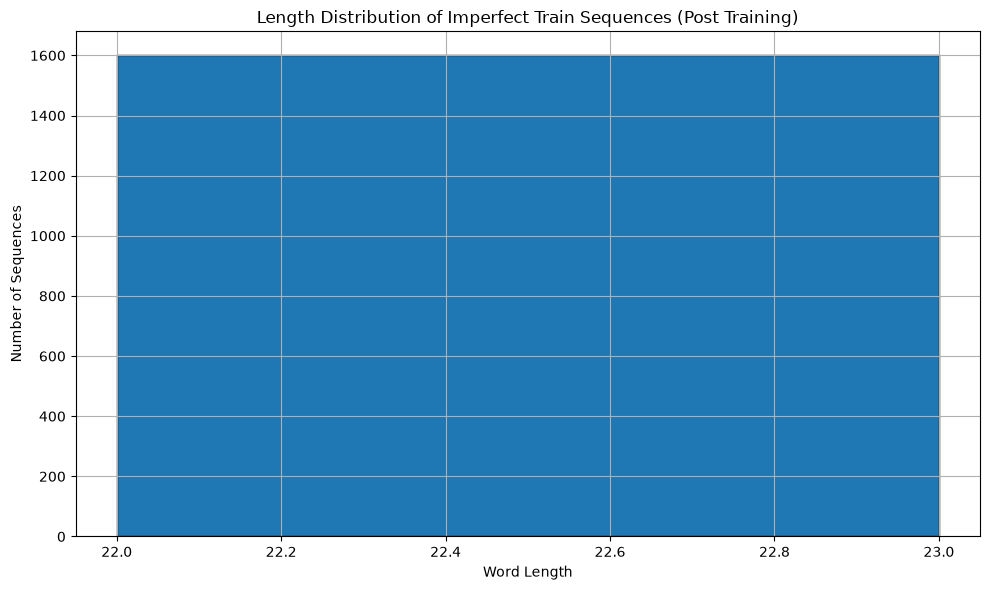

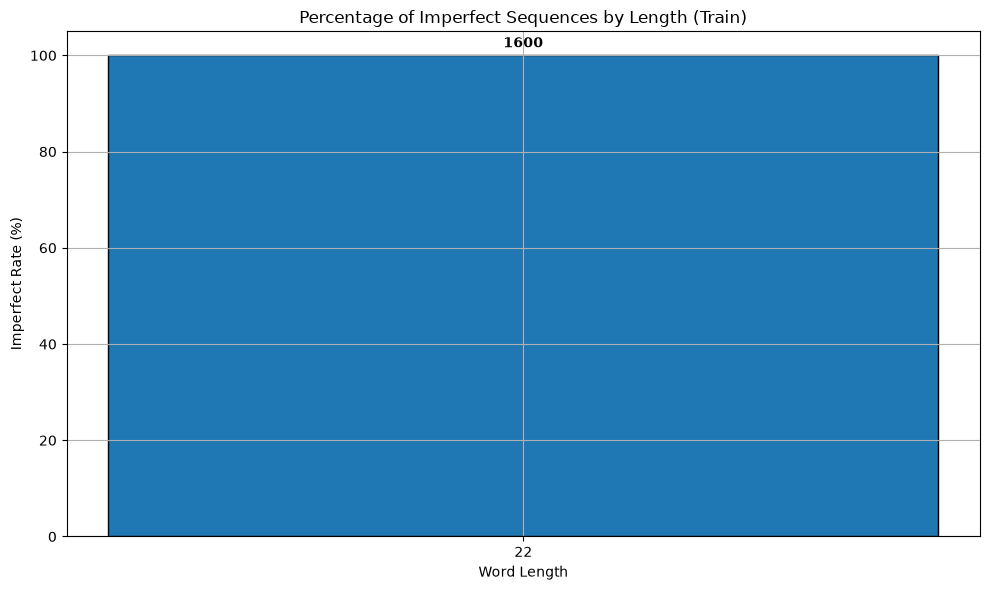

In [30]:
# Collect imperfect sequences (seq accuracy < 1.0)
imperfect = [
    (words[i], lengths[i], seq_accuracies[i], dataset_indices[i])
    for i in range(len(words)) if seq_accuracies[i] < 1.0
]

print("\nRandom Sample of Imperfect Train Sequences:")
for word, length, acc, idx in random.sample(imperfect, min(20, len(imperfect))):
    print(f"Word: {word} | Length: {length} | Seq Acc: {acc:.3f} | Index: {idx}")

# Plot 1: Raw length distribution of imperfect sequences
imperfect_lengths = [length for _, length, _, _ in imperfect]
plt.figure(figsize=(10, 6))
plt.hist(imperfect_lengths, bins=range(min(imperfect_lengths), max(imperfect_lengths)+2), edgecolor='black')
plt.title("Length Distribution of Imperfect Train Sequences (Post Training)")
plt.xlabel("Word Length")
plt.ylabel("Number of Sequences")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Percentage imperfect per length
lengths_sorted        = sorted(total_by_length.keys())
percent_misclassified = [100 * misclassified_by_length[l] / total_by_length[l] for l in lengths_sorted]
misclassified_counts  = [misclassified_by_length[l] for l in lengths_sorted]

plt.figure(figsize=(10, 6))
bars = plt.bar(lengths_sorted, percent_misclassified, edgecolor='black')

for bar, count in zip(bars, misclassified_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{count}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Percentage of Imperfect Sequences by Length (Train)")
plt.xlabel("Word Length")
plt.ylabel("Imperfect Rate (%)")
plt.xticks(lengths_sorted)
plt.grid(True)
plt.tight_layout()
plt.show()

### Test Misclassification Graphs


Random Sample of Imperfect Test Sequences:
Word: 3 2 3 1 2 1 2 1 3 1 2 1 2 1 2 1 2 3 1 3 1 0 | Length: 21 | Seq Acc: 0.619 | Index: 68
Word: 1 2 1 2 3 1 2 1 2 1 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 10 | Seq Acc: 0.900 | Index: 526
Word: 2 1 3 2 3 1 2 1 2 3 1 2 1 2 1 3 1 3 1 3 1 0 | Length: 21 | Seq Acc: 0.571 | Index: 1659
Word: 2 1 3 2 3 1 3 2 1 3 1 3 2 3 2 3 0 0 0 0 0 0 | Length: 16 | Seq Acc: 0.938 | Index: 2261
Word: 2 1 2 1 2 3 2 3 1 3 1 2 1 2 3 2 1 3 2 3 2 0 | Length: 21 | Seq Acc: 0.619 | Index: 1275
Word: 1 2 3 1 3 2 3 1 2 1 2 3 2 0 0 0 0 0 0 0 0 0 | Length: 13 | Seq Acc: 0.923 | Index: 546
Word: 2 1 2 3 1 2 1 2 1 3 1 2 3 1 2 1 3 2 1 2 1 3 | Length: 22 | Seq Acc: 0.682 | Index: 493
Word: 3 2 1 3 2 3 1 2 1 2 1 2 1 3 2 3 1 3 0 0 0 0 | Length: 18 | Seq Acc: 0.722 | Index: 2256
Word: 3 2 3 1 2 1 3 2 3 1 3 1 3 1 2 1 2 1 3 1 0 0 | Length: 20 | Seq Acc: 0.500 | Index: 1748
Word: 2 1 2 1 2 1 2 1 2 3 2 3 1 2 1 3 1 3 1 0 0 0 | Length: 19 | Seq Acc: 0.684 | Index: 851
Word: 3 1 3 1 3 1 3 2 

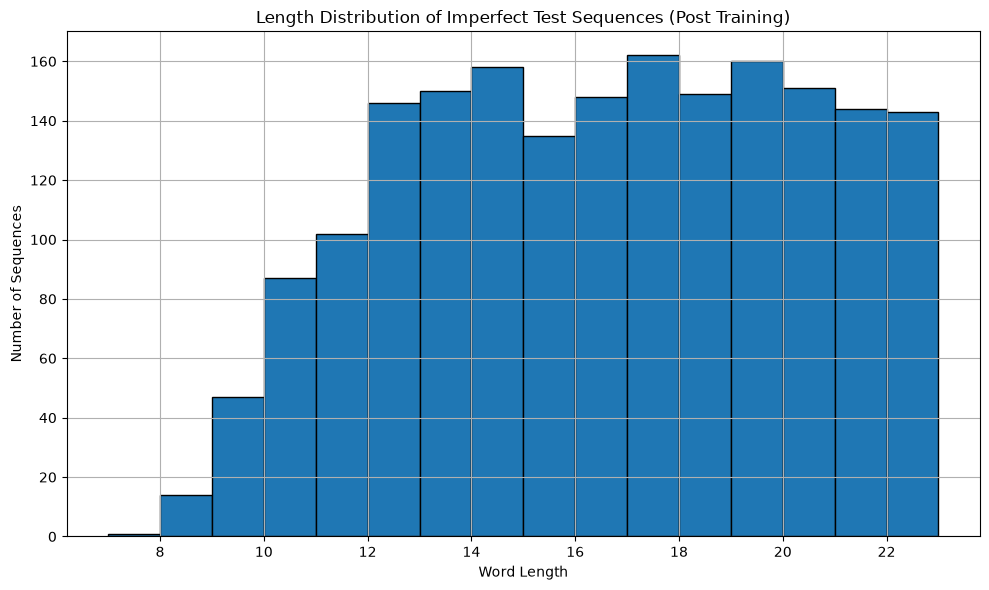

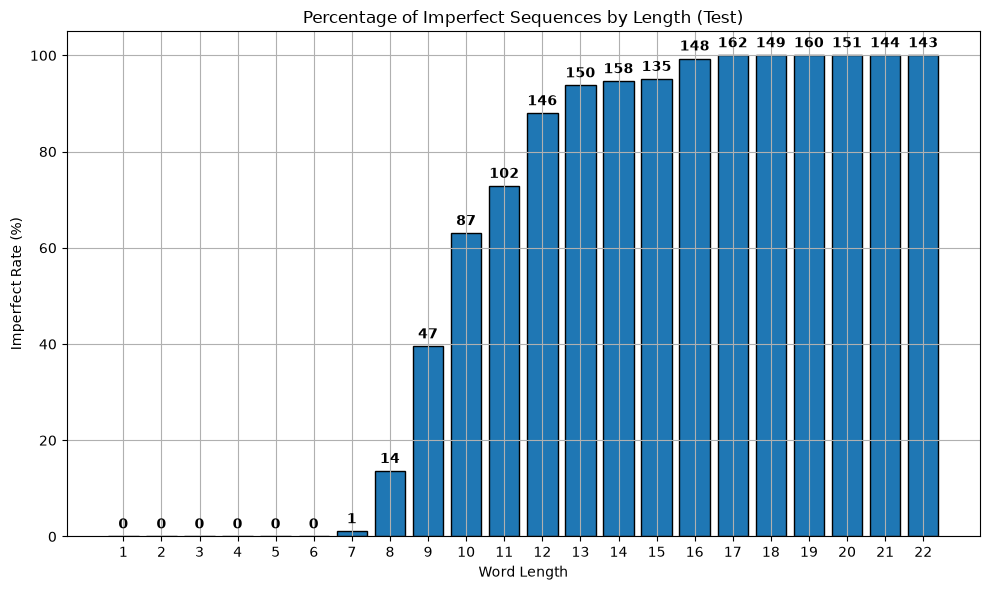

In [35]:
words = []
seq_accuracies = []
lengths = []
dataset_indices = []

total_by_length         = defaultdict(int)
misclassified_by_length = defaultdict(int)

test_tokens   = test_tokens.to(device1)
test_seq_acc  = getPredictions(model, test_tokens, test_targets, test_mask)

for i in range(len(test_tokens)):
    input_seq = test_tokens[i]
    word_str  = ' '.join([str(int(tok)) for tok in input_seq.tolist()])
    word_len  = (input_seq != 0).sum().item()   # no special token in the new format

    words.append(word_str)
    seq_accuracies.append(test_seq_acc[i].item())
    lengths.append(word_len)
    dataset_indices.append(i)

    total_by_length[word_len] += 1
    if test_seq_acc[i].item() < 1.0:
        misclassified_by_length[word_len] += 1

imperfect = [
    (words[i], lengths[i], seq_accuracies[i], dataset_indices[i])
    for i in range(len(words)) if seq_accuracies[i] < 1.0
]

print("\nRandom Sample of Imperfect Test Sequences:")
for word, length, acc, idx in random.sample(imperfect, min(20, len(imperfect))):
    print(f"Word: {word} | Length: {length} | Seq Acc: {acc:.3f} | Index: {idx}")

# Plot 1: Raw length distribution of imperfect sequences
imperfect_lengths = [length for _, length, _, _ in imperfect]
plt.figure(figsize=(10, 6))
plt.hist(imperfect_lengths, bins=range(min(imperfect_lengths), max(imperfect_lengths)+2), edgecolor='black')
plt.title("Length Distribution of Imperfect Test Sequences (Post Training)")
plt.xlabel("Word Length")
plt.ylabel("Number of Sequences")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Percentage imperfect per length
lengths_sorted        = sorted(total_by_length.keys())
percent_misclassified = [100 * misclassified_by_length[l] / total_by_length[l] for l in lengths_sorted]
misclassified_counts  = [misclassified_by_length[l] for l in lengths_sorted]

plt.figure(figsize=(10, 6))
bars = plt.bar(lengths_sorted, percent_misclassified, edgecolor='black')

for bar, count in zip(bars, misclassified_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{count}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Percentage of Imperfect Sequences by Length (Test)")
plt.xlabel("Word Length")
plt.ylabel("Imperfect Rate (%)")
plt.xticks(lengths_sorted)
plt.grid(True)
plt.tight_layout()
plt.show()

### Other Graphs
- check on misclassified
- attention heads of random selection of misclassified train inputs

In [36]:
print(f"total word count: {sum(total_by_length.values())}")
print(f"total misclassified count: {sum(misclassified_by_length.values())}")

total word count: 2400
total misclassified count: 1897


In [37]:
# Prints 1 graph per attention head
# x: letters (keys attended to)
# y: letters (query giving attention to x axis)

# Make sure there are at least 4 items to sample from
sample_size = min(4, len(misclassified))

# Take random sample of misclassified items
sample = random.sample(misclassified, sample_size)

misclassified_index = [index for _, _, _, index in sample]
# Move to test device, because it has more memory
for mis_index in misclassified_index:
    chosenWord = test_tokens[mis_index].unsqueeze(0).to(device1)  # shape (1, 22)


    # Generate labeled tokens with position

    # ex: word len 22: str_tokens = [0,...,21]
    str_tokens = [f"{i}" for i, tok in enumerate(chosenWord[0])]

    # Visualize
    n_heads = model.cfg.n_heads
    n_layers = model.cfg.n_layers
    for layer in range(n_layers):
        for head in range(n_heads):
            # gets the attention pattern for layer 0, pick 1 word from the batch and look at 1 head for it
            # detatch tensor from computation graph (no gradients), move tensor to cpu to make imshow heatmap
            attn_single_head = cache["pattern", layer][mis_index, head].detach().cpu()
            
            imshow(
                attn_single_head,
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} Attention Pattern (for word {mis_index})(Positional Tokens)"
            )

NameError: name 'misclassified' is not defined